# Confusion Matrix

In [ ]:
# 👉 Ye ek table hoti hai jo batati hai:
# Model ne kitni predictions sahi ki aur kitni galat

# 4 Terms samajh lo
# ✅ 1. TP (True Positive)

# 👉 Actual = Positive, Prediction = Positive
# ✔️ Sahi prediction

# ❌ 2. FP (False Positive)

# 👉 Actual = Negative, Prediction = Positive
# ❌ Galat (false alarm)

# ❌ 3. FN (False Negative)

# 👉 Actual = Positive, Prediction = Negative
# ❌ Dangerous mistake

# ✅ 4. TN (True Negative)

# 👉 Actual = Negative, Prediction = Negative
# ✔️ Sahi


# Example -
# Suppose:

# Email spam detection
# | Case | Meaning                     |
# | ---- | --------------------------- |
# | TP   | Spam → Spam (correct)       |
# | FP   | Normal → Spam (galat)       |
# | FN   | Spam → Normal (dangerous ❗) |
# | TN   | Normal → Normal             |


# 📊 Metrics from Confusion Matrix

# Socho tum job selection model bana rahe ho:
# Model bolta hai: “Ye candidate select hoga”
# Actual me kya hua → wahi compare karte hain

# 🔹 1. Accuracy
##  (TP + TN) / Total

# 👉 Meaning:
# Total me se kitne predictions sahi the


# 🔹 2. Precision
##  TP / (TP + FP)

# 👉 Meaning:
# Model ne jitne “Positive” bole, unme se kitne sach me positive the
# 👉 Precision = Pure predictions


# 🔹 3. Recall
##  TP / (TP + FN)

# 👉 Meaning:
# Actual positives me se kitne model ne pakde


# 4. F1 Score
##   2 * (Precision * Recall) / (Precision + Recall)

# 👉 Meaning:
# Precision + Recall ka balance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\archive\AI Job Market Dataset.csv")
df.head(3)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9


In [4]:
x = df.iloc[:, :-1]
y = df["job_openings"]

In [5]:
from sklearn.model_selection import train_test_split

In [13]:
x = pd.get_dummies(x, drop_first=True)
# text/string columns ko numeric me convert kar diya

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42, test_size=0.2)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
x.select_dtypes(include="object").columns
# 👉 Kaunse columns text/string type ke hain

Index([], dtype='object')

In [17]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

c:\Users\harsh\Desktop\Saloni\ML\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
lr.score(x_test, y_test)*100

12.083131947800869

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [22]:
cf = confusion_matrix(y_test, lr.predict(x_test))
cf

array([[ 14,   0,   5,   0,   0,   0, 192,   6,  17],
       [ 11,   0,  10,   0,   0,   0, 192,   9,  16],
       [  9,   0,  15,   0,   0,   0, 173,   3,  14],
       [ 19,   0,  14,   0,   0,   0, 183,   4,  17],
       [ 10,   0,  17,   0,   0,   0, 185,   1,  17],
       [ 12,   0,   5,   0,   0,   0, 172,   4,  15],
       [ 12,   0,   7,   0,   0,   0, 198,   6,  16],
       [ 13,   0,   9,   0,   0,   0, 186,   8,  10],
       [ 11,   0,  14,   0,   0,   0, 198,   5,  15]])

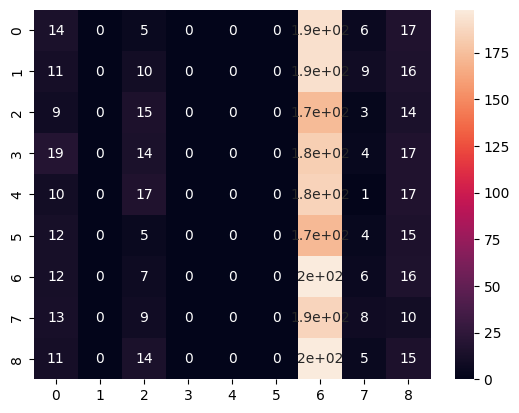

In [23]:
sns.heatmap(cf, annot=True)
plt.show()

In [ ]:
# Precision calculate kar rahe hain (weighted average)
# weighted → sab classes ka precision unke support (data count) ke according
# *100 → percentage me convert karne ke liye

precision_score(y_test, lr.predict(x_test), average="weighted") * 100

c:\Users\harsh\Desktop\Saloni\ML\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


7.590422158830393

In [28]:
recall_score(y_test, lr.predict(x_test), average="weighted") * 100

12.083131947800869

In [29]:
f1_score(y_test, lr.predict(x_test), average="weighted") * 100

5.873584395346608